In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# parameter values

E_h = 48 / 1_000_000    # Annual emissions of an ordinary household

H = 130_000_000    # Total of U.S households
Lambda = 0.1    # Portion of rich households 
m_e = 2.85    # Rich household’s emission multiplier

alpha = 5.25    # Multiplier for the excess emissions of the climate-advocate celebrity relative to the U.S. household
beta = 19.9    #  Multiplier for the excess emissions of the EV_industry innovator relative to the U.S. household
gamma = 19.9    #Multiplier for the excess emissions of the climate-skeptical politician relative to the U.S. household

theta_d = 0.82    # The domestic share of total consumption
theta_nd = 0.18    # The non-domestic share of total consumption

R_inf_CA = 0.03    # Climate advocate celebrity’s social influence


n_EV_sell = 1_300_000    # Total annual number of EV sold in the U.S. in 2024
n_EV_pro = 1_100_000    # Number of EVs produced annually in the U.S.

E_r = 3.5    # Emissions reduction from driving one EV instead of an ICE
E_ext = 3.2    # Additional emissions of producing one EV compared to an ICE

delta = 0.47    # Percentage reduction in EV productions under climate-skeptical presidency effect
sigma = 0.47    # Percentage reduction in EV sales under climate-skeptical presidency effect

m_1 = 2    # EV market expansion multiplier under climate-supportive policy 
m_2 = 1    # EV market expansion multiplier under climate-skeptical policy


S_p = 1    # Climate-skeptical presidency effect

In [34]:
# Reference parameter values for roles and thresholds

R_v0 = 1    # Reference value of voting role in Scenarios 2,3, and 4
R_v0_CS = 1.1    # Reference value of voting role in Scenarios 5 and 6  
R_p0 = 0.7    # Reference value of politician role
R_f0 = 0.8    # Reference value of firm-manager role
p = 1    # Politician role threshold determining the EV-policy regime
v = 1    # Voter role threshold for election of climate skeptical president    

Scenario 1:

In [35]:

def scenario_1(E_h, H, Lambda, m_e, alpha, beta, gamma, theta_d, theta_nd):

    # Illustrative ultra-rich actors' footprints

    climate_advocate_celebrity_footprint = alpha * E_h
    EV_industry_innovator_footprint = beta * E_h
    climate_skeptical_politician_footprint = gamma * E_h

    illustrative_actors_footprint = (
        climate_advocate_celebrity_footprint
        + EV_industry_innovator_footprint
        + climate_skeptical_politician_footprint
    )


    # Ordinary and rich households' footprints

    ordinary_households_footprint = (
        (1 - Lambda) * H * E_h
    )

    rich_households_footprint = (
        (Lambda * H - 3) * m_e * E_h
        + illustrative_actors_footprint
    )


    # Consumer role

    consumer_role = (
        rich_households_footprint
        + ordinary_households_footprint
    )


    # Domestic and non-domestic consumption

    domestic_households_consumption = (
        theta_d * consumer_role
    )

    non_domestic_households_consumption = (
        theta_nd * consumer_role
    )


    # Total emissions

    emissions = (
        domestic_households_consumption
        + non_domestic_households_consumption
    )

    return emissions

In [36]:
#Carbon footprint of the U.S. society

emissions_s1 = scenario_1(E_h, H, Lambda, m_e, alpha, beta, gamma, theta_d, theta_nd)

print(emissions_s1)

7394.401752


Scenario 2:

In [37]:
def scenario_2(
    E_h, H, Lambda, m_e,
    alpha, beta, gamma,
    theta_d, theta_nd,
    R_v0, R_p0, R_f0
):

    # Illustrative ultra-rich actors' footprints

    climate_advocate_celebrity_footprint = alpha * E_h
    EV_industry_innovator_footprint = beta * E_h
    climate_skeptical_politician_footprint = gamma * E_h

    illustrative_actors_footprint = (
        climate_advocate_celebrity_footprint
        + EV_industry_innovator_footprint
        + climate_skeptical_politician_footprint
    )


    # Ordinary and rich households' footprints

    ordinary_households_footprint = (
        (1 - Lambda) * H * E_h
    )

    rich_households_footprint = (
        (Lambda * H - 3) * m_e * E_h
        + illustrative_actors_footprint
    )


    # Consumer role

    consumer_role = (
        rich_households_footprint
        + ordinary_households_footprint
    )


    # Voter role

    voter_role = R_v0


    # Politician role

    politician_role = R_p0 * voter_role


    # Firm-manager role

    firm_manager_role = R_f0 * politician_role


    # Domestic and non-domestic consumption

    domestic_households_consumption = (
        politician_role
        * firm_manager_role
        * theta_d
        * consumer_role
    )

    non_domestic_households_consumption = (
        politician_role
        * theta_nd
        * consumer_role
    )


    # Total emissions

    emissions = (
        domestic_households_consumption
        + non_domestic_households_consumption
    )

    return emissions

In [38]:
# Climate lifeprint of the U.S. society

emissions_s2 = scenario_2(
    E_h, H, Lambda, m_e,
    alpha, beta, gamma,
    theta_d, theta_nd,
    R_v0, R_p0, R_f0
)

print(emissions_s2)

3308.5511199148796


In [39]:
# Scenario 3

def scenario_3(
    E_h, H, Lambda, m_e,
    alpha, beta, gamma,
    theta_d, theta_nd,
    R_v0, R_p0, R_f0,
    R_inf_CA
):

    # Illustrative ultra-rich actors' footprints

    climate_advocate_celebrity_footprint = alpha * E_h
    EV_industry_innovator_footprint = beta * E_h
    climate_skeptical_politician_footprint = gamma * E_h

    illustrative_actors_footprint = (
        climate_advocate_celebrity_footprint
        + EV_industry_innovator_footprint
        + climate_skeptical_politician_footprint
    )


    # Ordinary and rich households' footprints

    ordinary_households_footprint = (
        (1 - Lambda) * H * E_h
    )

    rich_households_footprint = (
        (Lambda * H - 3) * m_e * E_h
        + illustrative_actors_footprint
    )


    # Consumer role

    consumer_role = (
        rich_households_footprint
        + ordinary_households_footprint
    )


    # Voter role

    voter_role = R_v0 - R_inf_CA


    # Politician role

    politician_role = R_p0 * voter_role


    # Firm-manager role

    firm_manager_role = R_f0 * politician_role


    # Domestic and non-domestic consumption

    domestic_households_consumption = (
        politician_role
        * firm_manager_role
        * theta_d
        * consumer_role
    )

    non_domestic_households_consumption = (
        politician_role
        * theta_nd
        * consumer_role
    )


    # Total emissions

    emissions = (
        domestic_households_consumption
        + non_domestic_households_consumption
    )

    return emissions


In [40]:
emissions_s3 = scenario_3(
    E_h, H, Lambda, m_e,
    alpha, beta, gamma,
    theta_d, theta_nd,
    R_v0, R_p0, R_f0,
    R_inf_CA
)
print(emissions_s3)

3140.128062191793


In [67]:
# The climate-advocate celebrity's non-consumptive contribution

climate_advocate_celebrity_non_consumptive_effect = (
    emissions_s3 - emissions_s2
)

print(climate_advocate_celebrity_non_consumptive_effect)

-168.42305772308646


In [68]:
# The climate-advocate celebrity's footpirnt

climate_advocate_celebrity_footprint = alpha * E_h

print(climate_advocate_celebrity_footprint)


# The climate-advocate celebrity's lifeprint

climate_advocate_celebrity_lifeprint = (
    climate_advocate_celebrity_footprint
    + climate_advocate_celebrity_non_consumptive_effect
)


print(climate_advocate_celebrity_non_consumptive_effect)

print( climate_advocate_celebrity_lifeprint)


0.000252
-168.42305772308646
-168.42280572308647


Scenario 4:

In [42]:
def scenario_4(
    E_h, H, Lambda, m_e,
    alpha, beta, gamma,
    theta_d, theta_nd,
    R_v0, R_p0, R_f0,
    n_EV_sell, n_EV_pro,
    E_r, E_ext,
    delta, sigma,
    m_1, m_2,
    p
):

    # Illustrative ultra-rich actors' footprints

    climate_advocate_celebrity_footprint = alpha * E_h
    EV_industry_innovator_footprint = beta * E_h
    climate_skeptical_politician_footprint = gamma * E_h

    illustrative_actors_footprint = (
        climate_advocate_celebrity_footprint
        + EV_industry_innovator_footprint
        + climate_skeptical_politician_footprint
    )


    # Ordinary and rich households' footprints

    ordinary_households_footprint = (
        (1 - Lambda) * H * E_h
    )

    rich_households_footprint = (
        (Lambda * H - 3) * m_e * E_h
        + illustrative_actors_footprint
    )


    # Consumer role

    consumer_role = (
        rich_households_footprint
        + ordinary_households_footprint
    )


    # Voter role

    voter_role = R_v0


    # Politician role

    politician_role = R_p0 * voter_role


    # Firm-manager role

    firm_manager_role = R_f0 * politician_role


    # EV market expansion multiplier

    if politician_role <= p:
        ev_market_expansion_multiplier = m_1
    else:
        ev_market_expansion_multiplier = m_2


    # EV driving emissions saving

    if politician_role <= p:
        ev_driving_emissions_savings = (
            n_EV_sell * E_r / 1_000_000
        )
    else:
        ev_driving_emissions_savings = (
            n_EV_sell
            * (1 - sigma)
            * E_r
            / 1_000_000
        )


    # EV impact on consumption

    ev_impact_on_consumption = (
        ev_driving_emissions_savings
        * ev_market_expansion_multiplier
    )


    # Extra emissions from EV production

    if politician_role <= p:
        extra_emissions_from_ev_production = (
            n_EV_pro * E_ext / 1_000_000
        )
    else:
        extra_emissions_from_ev_production = (
            n_EV_pro
            * (1 - delta)
            * E_ext
            / 1_000_000
        )


    # Domestic and non-domestic consumption

    domestic_households_consumption = (
        politician_role
        * firm_manager_role
        * theta_d
        * consumer_role
        - ev_impact_on_consumption
        + extra_emissions_from_ev_production
    )

    non_domestic_households_consumption = (
        politician_role
        * theta_nd
        * consumer_role
    )


    # Total emissions

    emissions = (
        domestic_households_consumption
        + non_domestic_households_consumption
    )

    return emissions

In [43]:
emissions_s4 = scenario_4(
    E_h,
    H,
    Lambda,
    m_e,
    alpha,
    beta,
    gamma,
    theta_d,
    theta_nd,
    R_v0,
    R_p0,
    R_f0,
    n_EV_sell,
    n_EV_pro,
    E_r,
    E_ext,
    delta,
    sigma,
    m_1,
    m_2,
    p
)

print(emissions_s4)

3302.9711199148796


In [69]:
# The EV-industry innovator's non-consumptive contribution

EV_industry_innovator_non_consumptive_effect = (
    emissions_s4 - emissions_s2
)

print(EV_industry_innovator_non_consumptive_effect)

-5.579999999999927


In [72]:
# EV-industry innovator's footprint

EV_industry_innovator_footprint = beta * E_h

print (EV_industry_innovator_footprint)

# EV-industry innovator's lifeprint

EV_industry_innovator_lifeprint = (
    EV_industry_innovator_footprint
    + EV_industry_innovator_non_consumptive_effect
)

print(EV_industry_innovator_lifeprint)

0.0009551999999999999
-5.579044799999927


Scenario 5:

In [45]:
def scenario_5(
    E_h, H, Lambda, m_e,
    alpha, beta, gamma,
    theta_d, theta_nd,
    R_v0_CS, R_p0, R_f0,
    v, S_p
):

    # Illustrative ultra-rich actors' footprints

    climate_advocate_celebrity_footprint = alpha * E_h
    EV_industry_innovator_footprint = beta * E_h
    climate_skeptical_politician_footprint = gamma * E_h

    illustrative_actors_footprint = (
        climate_advocate_celebrity_footprint
        + EV_industry_innovator_footprint
        + climate_skeptical_politician_footprint
    )


    # Ordinary and rich households' footprints

    ordinary_households_footprint = (
        (1 - Lambda) * H * E_h
    )

    rich_households_footprint = (
        (Lambda * H - 3) * m_e * E_h
        + illustrative_actors_footprint
    )


    # Consumer role

    consumer_role = (
        rich_households_footprint
        + ordinary_households_footprint
    )


    # Voter role

    voter_role = R_v0_CS


    # Climate-skeptical presidenty effect

    if voter_role <= v:
        climate_skeptical_presidency_effect = 0
    else:
        climate_skeptical_presidency_effect = S_p


    # Politician role

    if climate_skeptical_presidency_effect <= 0:
        politician_role = R_p0 * voter_role
    else:
        politician_role = R_p0 + climate_skeptical_presidency_effect


    # Firm-manager role

    firm_manager_role = R_f0 * politician_role


    # Domestic and non-domestic consumption

    domestic_households_consumption = (
        politician_role
        * firm_manager_role
        * theta_d
        * consumer_role
    )

    non_domestic_households_consumption = (
        politician_role
        * theta_nd
        * consumer_role
    )


    # Total emissions

    emissions = (
        domestic_households_consumption
        + non_domestic_households_consumption
    )

    return emissions

In [46]:
emissions_s5 = scenario_5(
    E_h,
    H,
    Lambda,
    m_e,
    alpha,
    beta,
    gamma,
    theta_d,
    theta_nd,
    R_v0_CS,
    R_p0,
    R_f0,
    v,
     S_p
)

print(emissions_s5)

16281.28955362368


In [73]:
# The climate-skeptical politician's non-consumptive contribution

climate_skeptical_politician_non_consumptive_effect = (
    emissions_s5 - emissions_s2
)

print(climate_skeptical_politician_non_consumptive_effect)

12972.7384337088


In [75]:
# The climate-skeptical politician's footprint

climate_skeptical_politician_footprint = gamma * E_h

print(climate_skeptical_politician_footprint)

# The climate-skeptical politician's lifeprint

climate_skeptical_politician_lifeprint = (
    climate_skeptical_politician_footprint
    + climate_skeptical_politician_non_consumptive_effect
)

print(climate_skeptical_politician_lifeprint)

0.0009551999999999999
12972.7393889088


Scenario 6:

In [48]:
def scenario_6(
    E_h, H, Lambda, m_e,
    alpha, beta, gamma,
    theta_d, theta_nd,
    R_v0_CS, R_p0, R_f0,
    v, 
    n_EV_sell, n_EV_pro,
    E_r, E_ext,
    delta, sigma,
    m_1, m_2,
    p, S_p
):

    # Illustrative ultra-rich actors' footprints

    climate_advocate_celebrity_footprint = alpha * E_h
    EV_industry_innovator_footprint = beta * E_h
    climate_skeptical_politician_footprint = gamma * E_h

    illustrative_actors_footprint = (
        climate_advocate_celebrity_footprint
        + EV_industry_innovator_footprint
        + climate_skeptical_politician_footprint
    )


    # Ordinary and rich households' footprints

    ordinary_households_footprint = (
        (1 - Lambda) * H * E_h
    )

    rich_households_footprint = (
        (Lambda * H - 3) * m_e * E_h
        + illustrative_actors_footprint
    )


    # Consumer role

    consumer_role = (
        rich_households_footprint
        + ordinary_households_footprint
    )


    # Voter role

    voter_role = R_v0_CS


    # Climate-skeptical presidency

    if voter_role <= v:
        climate_skeptical_presidency_effect = 0
    else:
        climate_skeptical_presidency_effect = S_p


    # Politician role

    if climate_skeptical_presidency_effect <= 0:
        politician_role = R_p0 * voter_role
    else:
        politician_role = R_p0 + climate_skeptical_presidency_effect


    # Firm-manager role

    firm_manager_role = R_f0 * politician_role


    # EV market expansion multiplier

    if politician_role <= p:
        ev_market_expansion_multiplier = m_1
    else:
        ev_market_expansion_multiplier = m_2


    # EV driving emissions saving

    if politician_role <= p:
        ev_driving_emissions_savings = (
            n_EV_sell * E_r / 1_000_000
        )
    else:
        ev_driving_emissions_savings = (
            n_EV_sell
            * (1 - sigma)
            * E_r
            / 1_000_000
        )


    # EV impact on consumption

    ev_impact_on_consumption = (
        ev_driving_emissions_savings
        * ev_market_expansion_multiplier
    )


    # Extra emissions from EV production

    if politician_role <= p:
        extra_emissions_from_ev_production = (
            n_EV_pro * E_ext / 1_000_000
        )
    else:
        extra_emissions_from_ev_production = (
            n_EV_pro
            * (1 - delta)
            * E_ext
            / 1_000_000
        )


    # Domestic and non-domestic consumption

    domestic_households_consumption = (
        politician_role
        * firm_manager_role
        * theta_d
        * consumer_role
        - ev_impact_on_consumption
        + extra_emissions_from_ev_production
    )

    non_domestic_households_consumption = (
        politician_role
        * theta_nd
        * consumer_role
    )


    # Total emissions

    emissions = (
        domestic_households_consumption
        + non_domestic_households_consumption
    )

    return emissions

In [49]:
emissions_s6 = scenario_6(
    E_h,
    H,
    Lambda,
    m_e,
    alpha,
    beta,
    gamma,
    theta_d,
    theta_nd,
    R_v0_CS,
    R_p0,
    R_f0,
    v,
    n_EV_sell,
    n_EV_pro,
    E_r,
    E_ext,
    delta,
    sigma,
    m_1,
    m_2,
    p, S_p
)

print(emissions_s6)

16280.743653623678


In [77]:

# The joint non-consumptive contribution of the EV-industry innovator and the climate-skeptical politician

combined_non_consumptive_effect_skeptical_politician_EV_industry_innovator = (
    emissions_s6 - emissions_s2
)

print(combined_non_consumptive_effect_skeptical_politician_EV_industry_innovator)


12972.1925337088


In [79]:
# The joint footprint of the EV-industry innovator and the climate-skeptical politician

combined_footprint_skeptical_politician_EV_industry_innovator = (
    EV_industry_innovator_footprint
    + climate_skeptical_politician_footprint
)

print(combined_footprint_skeptical_politician_EV_industry_innovator)


# The joint lifeprint of the EV-industry innovator and the climate-skeptical politician

joint_lifeprint_skeptical_politician_EV_industry_innovator = (
    combined_footprint_skeptical_politician_EV_industry_innovator
    + combined_non_consumptive_effect_skeptical_politician_EV_industry_innovator)

print (joint_lifeprint_skeptical_politician_EV_industry_innovator)

0.0019103999999999998
12972.1944441088


Sensitivity analysis - One at a time (OAT)

    m_1  Scenario_4_emissions  E4_minus_E2
0   1.0            3307.52112       -1.030
1   1.1            3307.06612       -1.485
2   1.2            3306.61112       -1.940
3   1.3            3306.15612       -2.395
4   1.4            3305.70112       -2.850
5   1.5            3305.24612       -3.305
6   1.6            3304.79112       -3.760
7   1.7            3304.33612       -4.215
8   1.8            3303.88112       -4.670
9   1.9            3303.42612       -5.125
10  2.0            3302.97112       -5.580
11  2.1            3302.51612       -6.035
12  2.2            3302.06112       -6.490
13  2.3            3301.60612       -6.945
14  2.4            3301.15112       -7.400
15  2.5            3300.69612       -7.855
16  2.6            3300.24112       -8.310
17  2.7            3299.78612       -8.765
18  2.8            3299.33112       -9.220
19  2.9            3298.87612       -9.675
20  3.0            3298.42112      -10.130


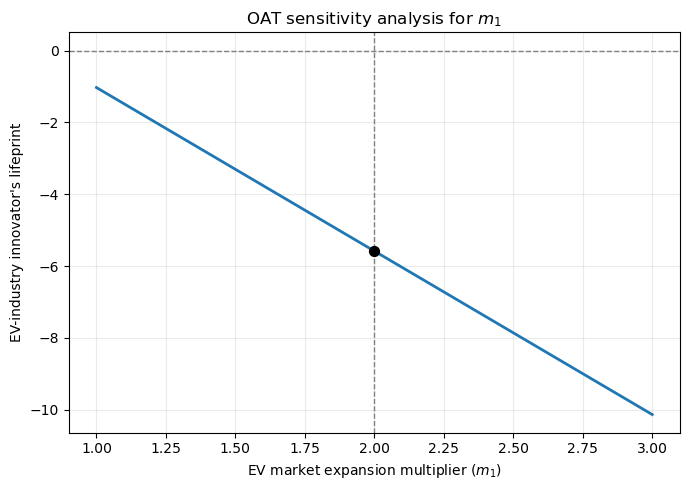

In [96]:
# Sensitivity analysis for parameter m_1
# range: m_1 = [1,3]
#influenced scenario: Scenario 4

m_1_values = np.linspace(1, 3, 21)

m_1_results = []

for m_1_test in m_1_values:

    emissions_s4_test = scenario_4(
        E_h,
        H,
        Lambda,
        m_e,
        alpha,
        beta,
        gamma,
        theta_d,
        theta_nd,
        R_v0,
        R_p0,
        R_f0,
        n_EV_sell,
        n_EV_pro,
        E_r,
        E_ext,
        delta,
        sigma,
        m_1_test,
        m_2,
        p
    )

    
    m_1_results.append([
        m_1_test,
        emissions_s4_test,
        emissions_s4_test - emissions_s2
    ])

# Table:

m_1_results_df = pd.DataFrame(
    m_1_results,
    columns=[
        "m_1",
        "Scenario_4_emissions",
        "E4_minus_E2"
    ]
)
    


m_1_results_df

print (m_1_results_df)


# Plot: 

plt.figure(figsize=(7, 5))


plt.plot(
    m_1_results_df["m_1"],
    m_1_results_df["E4_minus_E2"],
    linewidth=2
)


plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.axvline(
    x=m_1,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    m_1,
    emissions_s4 - emissions_s2,
    color="black",
    s=50,
    zorder=3,
    label="Baseline"
)

plt.xlabel("EV market expansion multiplier ($m_1$)")
plt.ylabel("EV-industry innovator's lifeprint")
plt.title("OAT sensitivity analysis for $m_1$")


plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


     m_2  Scenario_6_emissions   E6_minus_E2
0   0.50          16281.949404  12973.398284
1   0.55          16281.828829  12973.277709
2   0.60          16281.708254  12973.157134
3   0.65          16281.587679  12973.036559
4   0.70          16281.467104  12972.915984
5   0.75          16281.346529  12972.795409
6   0.80          16281.225954  12972.674834
7   0.85          16281.105379  12972.554259
8   0.90          16280.984804  12972.433684
9   0.95          16280.864229  12972.313109
10  1.00          16280.743654  12972.192534
11  1.05          16280.623079  12972.071959
12  1.10          16280.502504  12971.951384
13  1.15          16280.381929  12971.830809
14  1.20          16280.261354  12971.710234
15  1.25          16280.140779  12971.589659
16  1.30          16280.020204  12971.469084
17  1.35          16279.899629  12971.348509
18  1.40          16279.779054  12971.227934
19  1.45          16279.658479  12971.107359
20  1.50          16279.537904  12970.986784


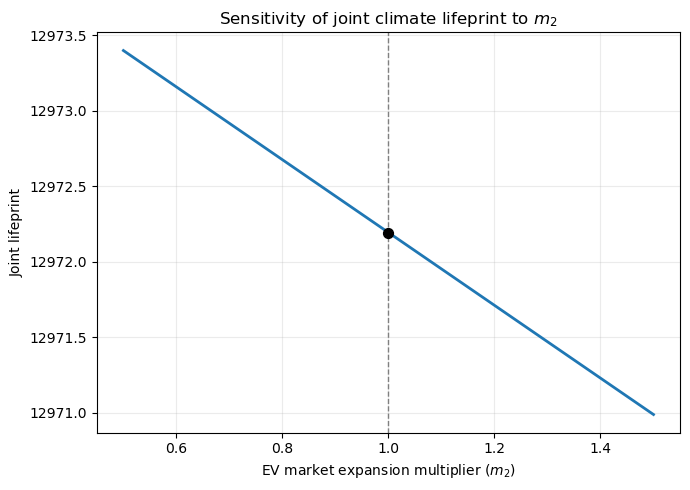

In [89]:
# Sensitivity analysis for parameter m_2
# range: m_2 = [0.5,1.5]
#influenced scenario: Scenario 6

m_2_values = np.linspace(0.5, 1.5, 21)

m_2_results = []

for m_2_test in m_2_values:

    emissions_s6_test = scenario_6(
        E_h,
        H,
        Lambda,
        m_e,
        alpha,
        beta,
        gamma,
        theta_d,
        theta_nd,
        R_v0_CS,
        R_p0,
        R_f0,
        v,
        n_EV_sell,
        n_EV_pro,
        E_r,
        E_ext,
        delta,
        sigma,
        m_1,
        m_2_test,
        p,
        S_p
    )

    

    m_2_results.append([
        m_2_test,
        emissions_s6_test,
        emissions_s6_test - emissions_s2
    ])
    

# Table:

m_2_results_df = pd.DataFrame(
    m_2_results,
    columns=[
        "m_2",
        "Scenario_6_emissions",
        "E6_minus_E2"
    ]
)

m_2_results_df

print(m_2_results_df)


# Plot:

plt.figure(figsize=(7, 5))


plt.plot(
    m_2_results_df["m_2"],
    m_2_results_df["E6_minus_E2"],
    linewidth=2
)


plt.axvline(
    x=m_2,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    m_2,
    emissions_s6 - emissions_s2,
    color="black",
    s=50,
    zorder=3,
    label="Baseline"
)

plt.xlabel("EV market expansion multiplier ($m_2$)")
plt.ylabel(
    "Joint lifeprint"
)

plt.title(
    "Sensitivity of joint climate lifeprint to $m_2$"
)


plt.grid(alpha=0.25)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.tight_layout()
plt.show()

        p  E4_minus_E2   E6_minus_E2
0    0.50      -0.5459  12972.192534
1    0.51      -0.5459  12972.192534
2    0.52      -0.5459  12972.192534
3    0.53      -0.5459  12972.192534
4    0.54      -0.5459  12972.192534
..    ...          ...           ...
146  1.96      -5.5800  12967.158434
147  1.97      -5.5800  12967.158434
148  1.98      -5.5800  12967.158434
149  1.99      -5.5800  12967.158434
150  2.00      -5.5800  12967.158434

[151 rows x 3 columns]


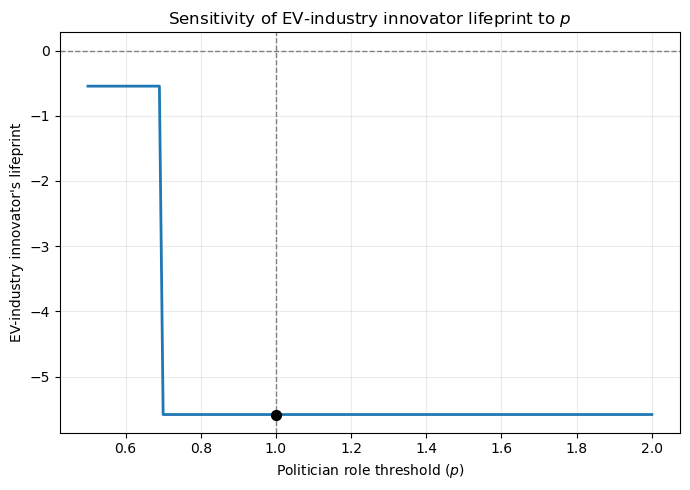

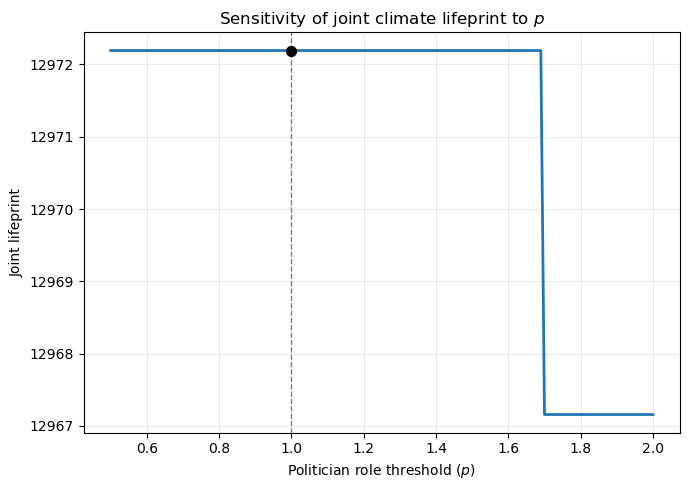

In [90]:
# Sensitivity analysis for parameter p
# range: p = [0.5,2]
#influenced scenario: Scenarios 4 and 6

p_values = np.linspace(0.5, 2.0, 151)

p_results = []

for p_test in p_values:

    # Scenario 4
    emissions_s4_test = scenario_4(
        E_h,
        H,
        Lambda,
        m_e,
        alpha,
        beta,
        gamma,
        theta_d,
        theta_nd,
        R_v0,
        R_p0,
        R_f0,
        n_EV_sell,
        n_EV_pro,
        E_r,
        E_ext,
        delta,
        sigma,
        m_1,
        m_2,
        p_test
    )

    # Scenario 6
    emissions_s6_test = scenario_6(
        E_h,
        H,
        Lambda,
        m_e,
        alpha,
        beta,
        gamma,
        theta_d,
        theta_nd,
        R_v0_CS,
        R_p0,
        R_f0,
        v,
        n_EV_sell,
        n_EV_pro,
        E_r,
        E_ext,
        delta,
        sigma,
        m_1,
        m_2,
        p_test,
        S_p
    )

    

    p_results.append([
        p_test,
        emissions_s4_test - emissions_s2,
        emissions_s6_test - emissions_s2
    ])


# Table:

p_results_df = pd.DataFrame(
    p_results,
    columns=[
        "p",
        "E4_minus_E2",
        "E6_minus_E2"
    ]
)

p_results_df

print(p_results_df)

# Plot for E4-E2

plt.figure(figsize=(7, 5))

plt.plot(
    p_results_df["p"],
    p_results_df["E4_minus_E2"],
    linewidth=2
)

plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    x=p,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.scatter(
    p,
    emissions_s4 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Politician role threshold ($p$)")
plt.ylabel(
    "EV-industry innovator's lifeprint"
)

plt.title(
    "Sensitivity of EV-industry innovator lifeprint to $p$"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot E6-E2

plt.figure(figsize=(7, 5))

plt.plot(
    p_results_df["p"],
    p_results_df["E6_minus_E2"],
    linewidth=2
)

plt.axvline(
    x=p,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.scatter(
    p,
    emissions_s6 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Politician role threshold ($p$)")
plt.ylabel(
    "Joint lifeprint"
)

plt.title(
    "Sensitivity of joint climate lifeprint to $p$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

    R_f0  E3_minus_E2  E4_minus_E2   E5_minus_E2   E6_minus_E2
0   0.60  -133.305003        -5.58  10062.301904  10061.756004
1   0.62  -136.816808        -5.58  10353.345557  10352.799657
2   0.64  -140.328614        -5.58  10644.389210  10643.843310
3   0.66  -143.840419        -5.58  10935.432863  10934.886963
4   0.68  -147.352225        -5.58  11226.476516  11225.930616
5   0.70  -150.864030        -5.58  11517.520169  11516.974269
6   0.72  -154.375836        -5.58  11808.563822  11808.017922
7   0.74  -157.887641        -5.58  12099.607475  12099.061575
8   0.76  -161.399447        -5.58  12390.651128  12390.105228
9   0.78  -164.911252        -5.58  12681.694781  12681.148881
10  0.80  -168.423058        -5.58  12972.738434  12972.192534
11  0.82  -171.934863        -5.58  13263.782087  13263.236187
12  0.84  -175.446669        -5.58  13554.825740  13554.279840
13  0.86  -178.958474        -5.58  13845.869393  13845.323493
14  0.88  -182.470280        -5.58  14136.913046  14136

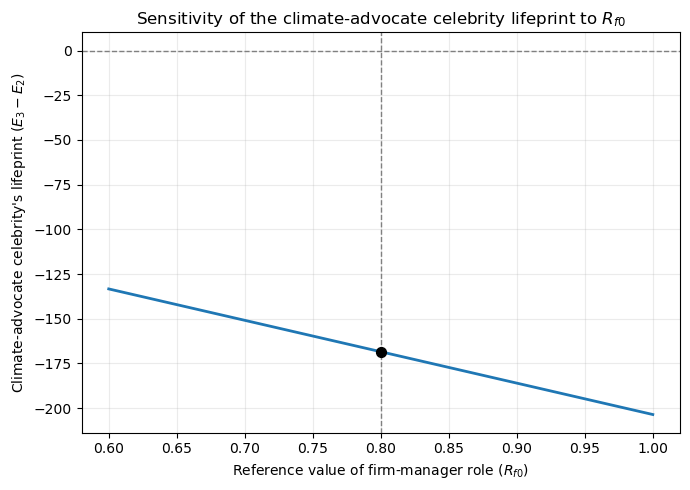

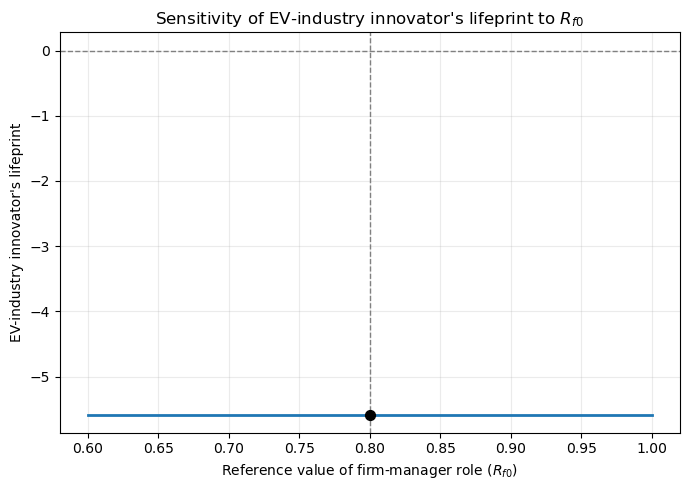

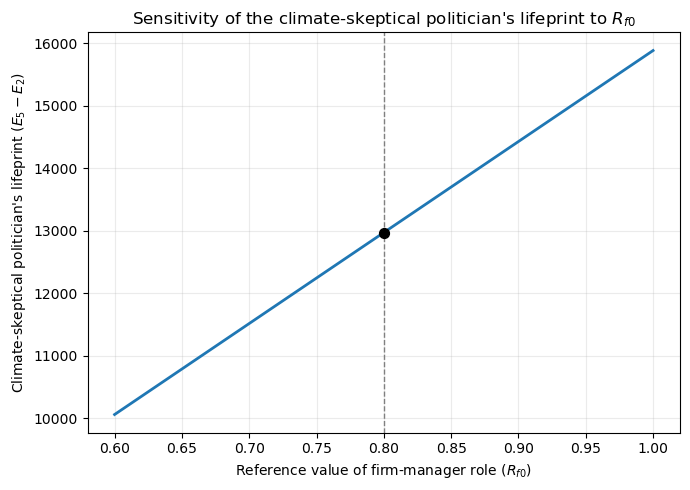

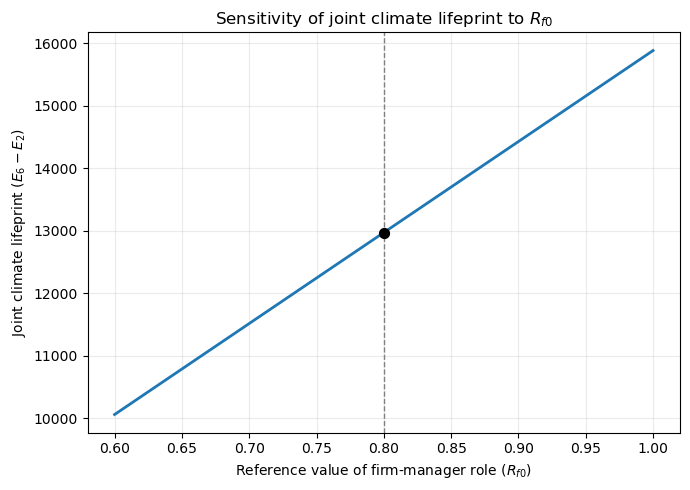

In [91]:
# Sensitivity analysis for parameter R_f0
# range: R_f0 = [0.6,1]
#influenced scenario: Scenarios 2, 3, 4, 5, 6

R_f0_values = np.linspace(0.6, 1.0, 21)

R_f0_results = []

for R_f0_test in R_f0_values:

    # Scenario 2
    emissions_s2_test = scenario_2(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0, R_p0, R_f0_test
    )

    # Scenario 3
    emissions_s3_test = scenario_3(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0, R_p0, R_f0_test,
        R_inf_CA
    )

    # Scenario 4
    emissions_s4_test = scenario_4(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0, R_p0, R_f0_test,
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta, sigma,
        m_1, m_2,
        p
    )

    # Scenario 5
    emissions_s5_test = scenario_5(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0, R_f0_test,
        v, S_p
    )

    # Scenario 6
    emissions_s6_test = scenario_6(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0, R_f0_test,
        v,
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta, sigma,
        m_1, m_2,
        p, S_p
    )

  

    R_f0_results.append([
        R_f0_test,
        emissions_s3_test - emissions_s2_test,
        emissions_s4_test - emissions_s2_test,
        emissions_s5_test - emissions_s2_test,
        emissions_s6_test - emissions_s2_test
    ])


# Table:

R_f0_results_df = pd.DataFrame(
    R_f0_results,
    columns=[
        "R_f0",
        "E3_minus_E2",
        "E4_minus_E2",
        "E5_minus_E2",
        "E6_minus_E2"
    ]
)

R_f0_results_df

print(R_f0_results_df)


#Plot:

# Plot for E3-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_f0_results_df["R_f0"],
    R_f0_results_df["E3_minus_E2"],
    linewidth=2
)


plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.axvline(
    x=R_f0,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    R_f0,
    emissions_s3 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of firm-manager role ($R_{f0}$) ")
plt.ylabel(
    "Climate-advocate celebrity's lifeprint ($E_3-E_2$)"
)

plt.title(
    "Sensitivity of the climate-advocate celebrity lifeprint to $R_{f0}$"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



# Plot for E4-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_f0_results_df["R_f0"],
    R_f0_results_df["E4_minus_E2"],
    linewidth=2
)


plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.axvline(
    x=R_f0,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    R_f0,
    emissions_s4 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of firm-manager role ($R_{f0}$)")
plt.ylabel(
    "EV-industry innovator's lifeprint"
)

plt.title(
    "Sensitivity of EV-industry innovator's lifeprint to $R_{f0}$"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



# Plot for E5-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_f0_results_df["R_f0"],
    R_f0_results_df["E5_minus_E2"],
    linewidth=2
)


plt.axvline(
    x=R_f0,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    R_f0,
    emissions_s5 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of firm-manager role ($R_{f0}$)")
plt.ylabel(
    "Climate-skeptical politician's lifeprint ($E_5-E_2$)"
)

plt.title(
    "Sensitivity of the climate-skeptical politician's lifeprint to $R_{f0}$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


#Plot for E6-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_f0_results_df["R_f0"],
    R_f0_results_df["E6_minus_E2"],
    linewidth=2
)


plt.axvline(
    x=R_f0,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    R_f0,
    emissions_s6 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of firm-manager role ($R_{f0}$)")
plt.ylabel(
    "Joint climate lifeprint ($E_6-E_2$)"
)

plt.title(
    "Sensitivity of joint climate lifeprint to $R_{f0}$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

    R_p0  E3_minus_E2  E4_minus_E2   E5_minus_E2   E6_minus_E2
0   0.50   -91.634384        -5.58  11032.447414  11031.901514
1   0.52   -98.281211        -5.58  11226.476516  11225.930616
2   0.54  -105.157380        -5.58  11420.505618  11419.959718
3   0.56  -112.262891        -5.58  11614.534720  11613.988820
4   0.58  -119.597745        -5.58  11808.563822  11808.017922
5   0.60  -127.161941        -5.58  12002.592924  12002.047024
6   0.62  -134.955480        -5.58  12196.622026  12196.076126
7   0.64  -142.978361        -5.58  12390.651128  12390.105228
8   0.66  -151.230584        -5.58  12584.680230  12584.134330
9   0.68  -159.712150        -5.58  12778.709332  12778.163432
10  0.70  -168.423058        -5.58  12972.738434  12972.192534
11  0.72  -177.363308        -5.58  13166.767536  13166.221636
12  0.74  -186.532901        -5.58  13360.796638  13360.250738
13  0.76  -195.931837        -5.58  13554.825740  13554.279840
14  0.78  -205.560114        -5.58  13748.854842  13748

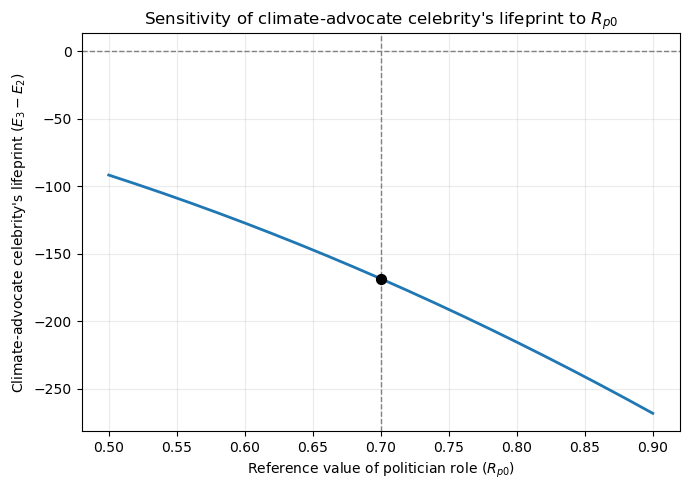

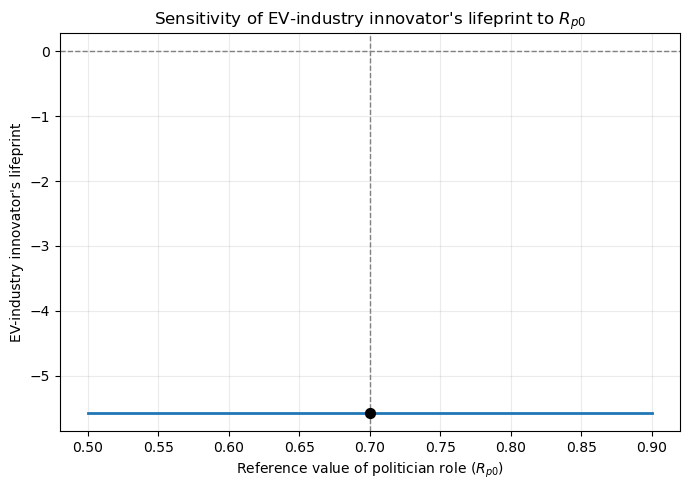

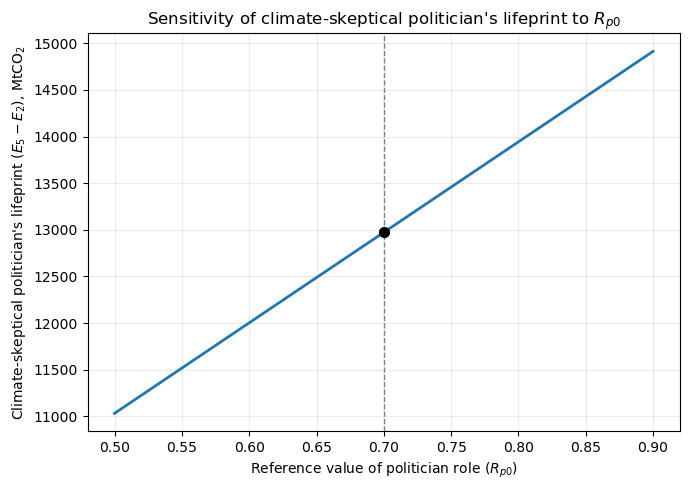

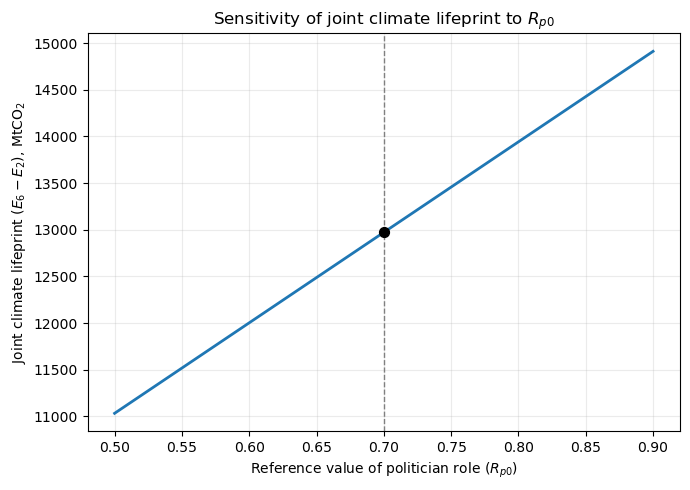

In [92]:
# Sensitivity analysis for parameter R_p0
# range: R_p0 = [0.5,0.9]
#influenced scenario: Scenarios 2, 3, 4, 5, 6

R_p0_values = np.linspace(0.5, 0.9, 21)

R_p0_results = []

for R_p0_test in R_p0_values:

    # Scenario 2
    emissions_s2_test = scenario_2(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0, R_p0_test, R_f0
    )

    # Scenario 3
    emissions_s3_test = scenario_3(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0, R_p0_test, R_f0,
        R_inf_CA
    )

    # Scenario 4
    emissions_s4_test = scenario_4(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0, R_p0_test, R_f0,
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta, sigma,
        m_1, m_2,
        p
    )

    # Scenario 5
    emissions_s5_test = scenario_5(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0_test, R_f0,
        v, S_p
    )

    # Scenario 6
    emissions_s6_test = scenario_6(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0_test, R_f0,
        v,
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta, sigma,
        m_1, m_2,
        p, S_p
    )

    R_p0_results.append([
        R_p0_test,
        emissions_s3_test - emissions_s2_test,
        emissions_s4_test - emissions_s2_test,
        emissions_s5_test - emissions_s2_test,
        emissions_s6_test - emissions_s2_test
    ])


# Table

R_p0_results_df = pd.DataFrame(
    R_p0_results,
    columns=[
        "R_p0",
        "E3_minus_E2",
        "E4_minus_E2",
        "E5_minus_E2",
        "E6_minus_E2"
    ]
)

R_p0_results_df

print (R_p0_results_df)


# Plot for E3-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_p0_results_df["R_p0"],
    R_p0_results_df["E3_minus_E2"],
    linewidth=2
)

plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    x=R_p0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.scatter(
    R_p0,
    emissions_s3 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of politician role ($R_{p0}$)")
plt.ylabel(
    "Climate-advocate celebrity's lifeprint ($E_3-E_2$)"
)

plt.title(
    "Sensitivity of climate-advocate celebrity's lifeprint to $R_{p0}$"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot for the E4-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_p0_results_df["R_p0"],
    R_p0_results_df["E4_minus_E2"],
    linewidth=2
)

plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    x=R_p0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.scatter(
    R_p0,
    emissions_s4 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of politician role ($R_{p0}$)")
plt.ylabel(
    "EV-industry innovator's lifeprint"
)

plt.title(
    "Sensitivity of EV-industry innovator's lifeprint to $R_{p0}$"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot for E5-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_p0_results_df["R_p0"],
    R_p0_results_df["E5_minus_E2"],
    linewidth=2
)

plt.axvline(
    x=R_p0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.scatter(
    R_p0,
    emissions_s5 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of politician role ($R_{p0}$)")
plt.ylabel(
    "Climate-skeptical politician's lifeprint ($E_5-E_2$), MtCO$_2$"
)

plt.title(
    "Sensitivity of climate-skeptical politician's lifeprint to $R_{p0}$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot for E6-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_p0_results_df["R_p0"],
    R_p0_results_df["E6_minus_E2"],
    linewidth=2
)

plt.axvline(
    x=R_p0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.scatter(
    R_p0,
    emissions_s6 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of politician role ($R_{p0}$)")
plt.ylabel(
    "Joint climate lifeprint ($E_6-E_2$), MtCO$_2$"
)

plt.title(
    "Sensitivity of joint climate lifeprint to $R_{p0}$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()




     R_v0  E3_minus_E2  E4_minus_E2
0   0.800  -139.900780        -5.58
1   0.805  -140.613837        -5.58
2   0.810  -141.326894        -5.58
3   0.815  -142.039951        -5.58
4   0.820  -142.753008        -5.58
..    ...          ...          ...
76  1.180  -194.093108        -5.58
77  1.185  -194.806165        -5.58
78  1.190  -195.519222        -5.58
79  1.195  -196.232279        -5.58
80  1.200  -196.945336        -5.58

[81 rows x 3 columns]


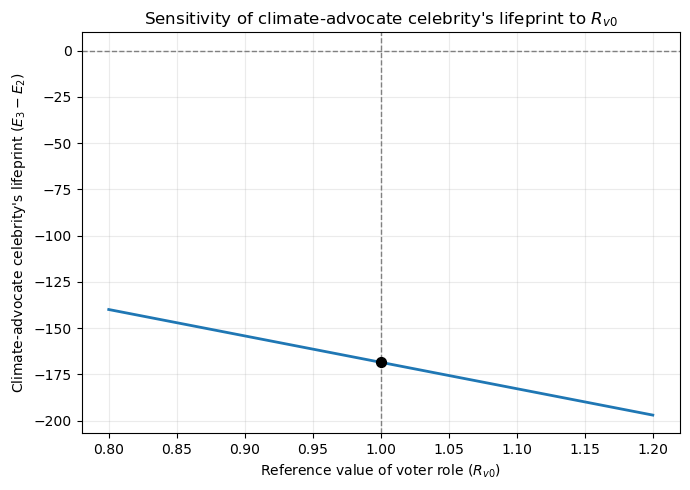

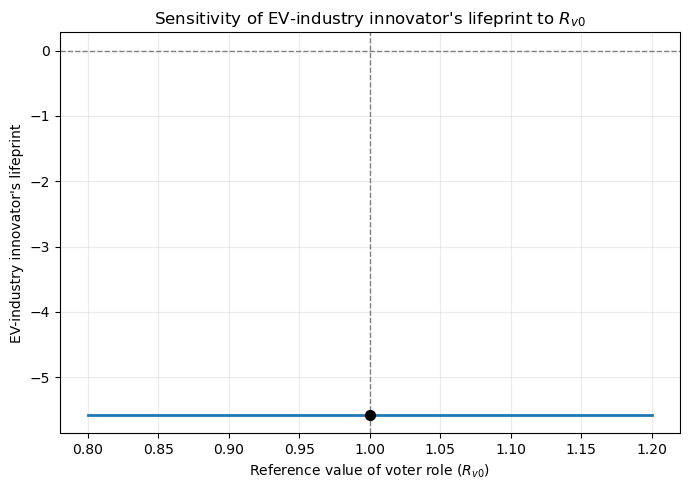

In [56]:
# Sensitivity analysis for parameter R_v0
# range: R_v0 = [0.8,1.2]
#influenced scenario: Scenarios 2, 3, and 4

R_v0_values = np.linspace(0.8, 1.2, 81)

R_v0_results = []


for R_v0_test in R_v0_values:

    # Scenario 2
    emissions_s2_test = scenario_2(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_test, R_p0, R_f0
    )

    # Scenario 3
    emissions_s3_test = scenario_3(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_test, R_p0, R_f0,
        R_inf_CA
    )

    # Scenario 4
    emissions_s4_test = scenario_4(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_test, R_p0, R_f0,
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta, sigma,
        m_1, m_2,
        p
    )

   
    R_v0_results.append([
        R_v0_test,
        emissions_s3_test - emissions_s2_test,
        emissions_s4_test - emissions_s2_test
    ])


# Table:

R_v0_results_df = pd.DataFrame(
    R_v0_results,
    columns=[
        "R_v0",
        "E3_minus_E2",
        "E4_minus_E2"
        
    ]
)

R_v0_results_df

print (R_v0_results_df)


# Plot E3-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_v0_results_df["R_v0"],
    R_v0_results_df["E3_minus_E2"],
    linewidth=2
)

plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    x=R_v0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.scatter(
    R_v0,
    emissions_s3 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of voter role ($R_{v0}$)")
plt.ylabel(
    "Climate-advocate celebrity's lifeprint ($E_3-E_2$)"
)

plt.title(
    "Sensitivity of climate-advocate celebrity's lifeprint to $R_{v0}$"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot for E4-E2

plt.figure(figsize=(7, 5))

plt.plot(
    R_v0_results_df["R_v0"],
    R_v0_results_df["E4_minus_E2"],
    linewidth=2
)

plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    x=R_v0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.scatter(
    R_v0,
    emissions_s4 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Reference value of voter role ($R_{v0}$)")
plt.ylabel(
    "EV-industry innovator's lifeprint"
)

plt.title(
    "Sensitivity of EV-industry innovator's lifeprint to $R_{v0}$"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()




    R_v0_CS   E5_minus_E2   E6_minus_E2
0      1.01  12972.738434  12972.192534
1      1.02  12972.738434  12972.192534
2      1.03  12972.738434  12972.192534
3      1.04  12972.738434  12972.192534
4      1.05  12972.738434  12972.192534
5      1.06  12972.738434  12972.192534
6      1.07  12972.738434  12972.192534
7      1.08  12972.738434  12972.192534
8      1.09  12972.738434  12972.192534
9      1.10  12972.738434  12972.192534
10     1.11  12972.738434  12972.192534
11     1.12  12972.738434  12972.192534
12     1.13  12972.738434  12972.192534
13     1.14  12972.738434  12972.192534
14     1.15  12972.738434  12972.192534
15     1.16  12972.738434  12972.192534
16     1.17  12972.738434  12972.192534
17     1.18  12972.738434  12972.192534
18     1.19  12972.738434  12972.192534
19     1.20  12972.738434  12972.192534


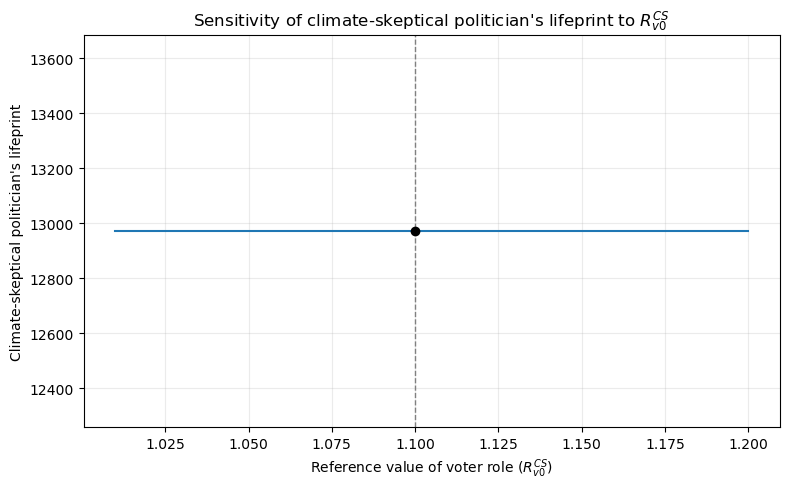

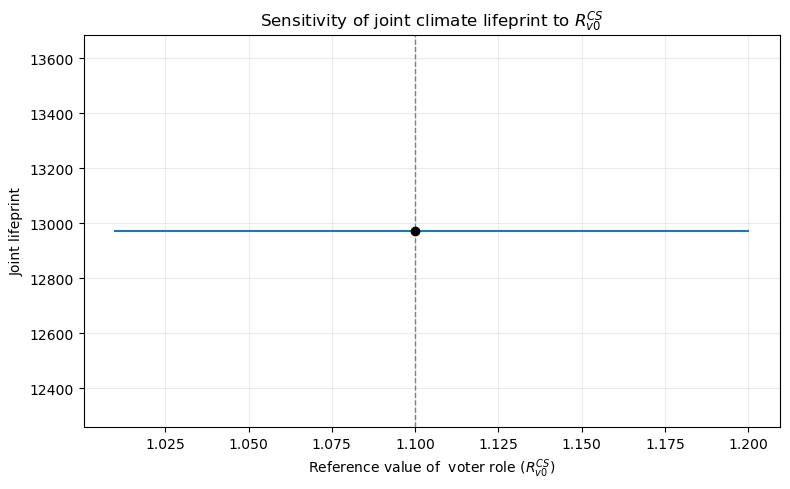

In [57]:
# Sensitivity analysis for parameter R_v0_CS
# range: R_v0_cs = [1.01,1.20]
#influenced scenario: Scenarios 5 and 6


R_v0_CS_values = np.linspace(1.01, 1.20, 20)

R_v0_CS_results = []


for R_v0_CS_test in R_v0_CS_values:

    # Scenario 5
    emissions_s5_test = scenario_5(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS_test, R_p0, R_f0,
        v,
        S_p
    )

    # Scenario 6
    emissions_s6_test = scenario_6(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS_test, R_p0, R_f0,
        v,
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta, sigma,
        m_1, m_2,
        p, S_p
    )

    R_v0_CS_results.append([
        R_v0_CS_test,
        emissions_s5_test - emissions_s2,
        emissions_s6_test - emissions_s2
    ])


# Table

R_v0_CS_results_df = pd.DataFrame(
    R_v0_CS_results,
    columns=[
        "R_v0_CS",
        "E5_minus_E2",
        "E6_minus_E2"
    ]
)

R_v0_CS_results_df

print(R_v0_CS_results_df)

# Plot for E5-E2

plt.figure(figsize=(8, 5))

plt.plot(
    R_v0_CS_results_df["R_v0_CS"],
    R_v0_CS_results_df["E5_minus_E2"]
)


baseline_E5 = R_v0_CS_results_df.loc[
    np.isclose(R_v0_CS_results_df["R_v0_CS"], 1.10),
    "E5_minus_E2"
].iloc[0]

plt.scatter(1.10, baseline_E5, color="black", zorder=3)


plt.axvline(
    x=1.10,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.xlabel(r"Reference value of voter role ($R_{v0}^{CS}$)")
plt.ylabel(r"Climate-skeptical politician's lifeprint")
plt.title(
    r"Sensitivity of climate-skeptical politician's lifeprint to $R_{v0}^{CS}$"
)

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot for E6-E2

plt.figure(figsize=(8, 5))

plt.plot(
    R_v0_CS_results_df["R_v0_CS"],
    R_v0_CS_results_df["E6_minus_E2"]
)


baseline_E6 = R_v0_CS_results_df.loc[
    np.isclose(R_v0_CS_results_df["R_v0_CS"], 1.10),
    "E6_minus_E2"
].iloc[0]

plt.scatter(1.10, baseline_E6, color="black", zorder=3)


plt.axvline(
    x=1.10,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.xlabel(r"Reference value of  voter role ($R_{v0}^{CS}$)")
plt.ylabel(r"Joint lifeprint")
plt.title(
    r"Sensitivity of joint climate lifeprint to $R_{v0}^{CS}$"
)

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()




     S_p   E5_minus_E2   E6_minus_E2
0   0.50   5273.687330   5273.141430
1   0.55   5934.451070   5933.905170
2   0.60   6619.468448   6618.922548
3   0.65   7328.739464   7328.193564
4   0.70   8062.264118   8061.718218
5   0.75   8820.042410   8819.496510
6   0.80   9602.074339   9601.528439
7   0.85  10408.359906  10407.814006
8   0.90  11238.899111  11238.353211
9   0.95  12093.691953  12093.146053
10  1.00  12972.738434  12972.192534
11  1.05  13876.038552  13875.492652
12  1.10  14803.592308  14803.046408
13  1.15  15755.399701  15754.853801
14  1.20  16731.460732  16730.914832
15  1.25  17731.775401  17731.229501
16  1.30  18756.343708  18755.797808
17  1.35  19805.165653  19804.619753
18  1.40  20878.241235  20877.695335
19  1.45  21975.570455  21975.024555
20  1.50  23097.153313  23096.607413


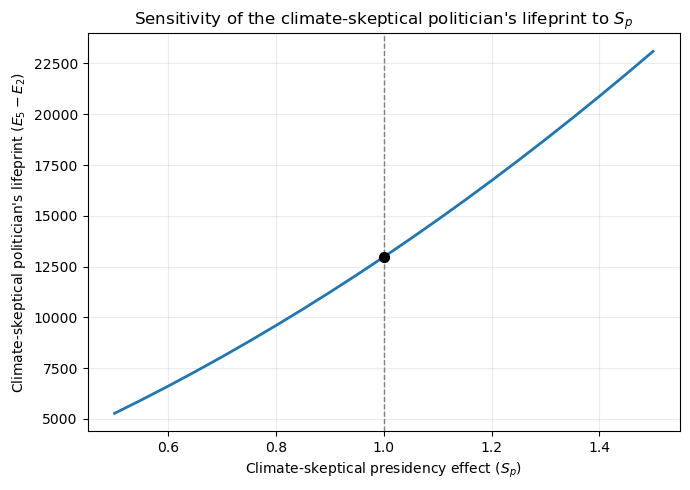

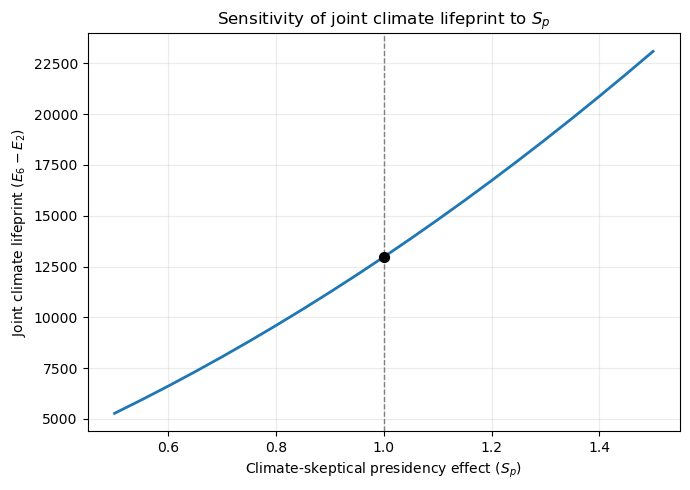

In [58]:
# Sensitivity analysis for parameter S_p
# range: S_p = [0.5,1.5]
#influenced scenario: Scenarios 5 and 6

S_p_values = np.linspace(0.5, 1.5, 21)

S_p_results = []

for S_p_test in S_p_values:

    # Scenario 5
    emissions_s5_test = scenario_5(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0, R_f0,
        v,  S_p_test
    )

    # Scenario 6
    emissions_s6_test = scenario_6(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0, R_f0,
        v,
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta, sigma,
        m_1, m_2,
        p, S_p_test
    )

    S_p_results.append([
        S_p_test,
        emissions_s5_test - emissions_s2,
        emissions_s6_test - emissions_s2
    ])


# Table:

S_p_results_df = pd.DataFrame(
    S_p_results,
    columns=[
        "S_p",
        "E5_minus_E2",
        "E6_minus_E2"
    ]
)

S_p_results_df

print (S_p_results_df)



# Plot E5-E2

plt.figure(figsize=(7, 5))

plt.plot(
    S_p_results_df["S_p"],
    S_p_results_df["E5_minus_E2"],
    linewidth=2
)


plt.axvline(
    x=S_p,
    color="gray",
    linestyle="--",
    linewidth=1
)

# Baseline result
plt.scatter(
    S_p,
    emissions_s5 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Climate-skeptical presidency effect ($S_p$)")
plt.ylabel(
    "Climate-skeptical politician's lifeprint ($E_5-E_2$)"
)

plt.title(
    "Sensitivity of the climate-skeptical politician's lifeprint to $S_p$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot for E6-E2

plt.figure(figsize=(7, 5))

plt.plot(
    S_p_results_df["S_p"],
    S_p_results_df["E6_minus_E2"],
    linewidth=2
)


plt.axvline(
    x=S_p,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    S_p,
    emissions_s6 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Climate-skeptical presidency effect ($S_p$)")
plt.ylabel(
    "Joint climate lifeprint ($E_6-E_2$)"
)

plt.title(
    "Sensitivity of joint climate lifeprint to $S_p$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

        v   E5_minus_E2   E6_minus_E2
0   0.800  12972.738434  12972.192534
1   0.805  12972.738434  12972.192534
2   0.810  12972.738434  12972.192534
3   0.815  12972.738434  12972.192534
4   0.820  12972.738434  12972.192534
..    ...           ...           ...
76  1.180    592.309327    586.729327
77  1.185    592.309327    586.729327
78  1.190    592.309327    586.729327
79  1.195    592.309327    586.729327
80  1.200    592.309327    586.729327

[81 rows x 3 columns]


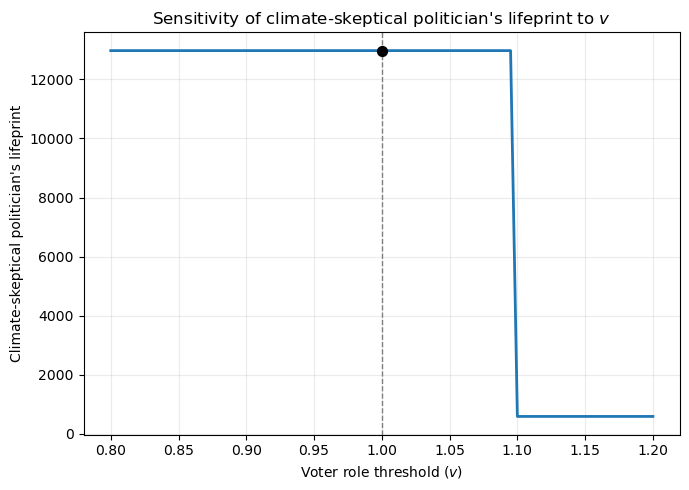

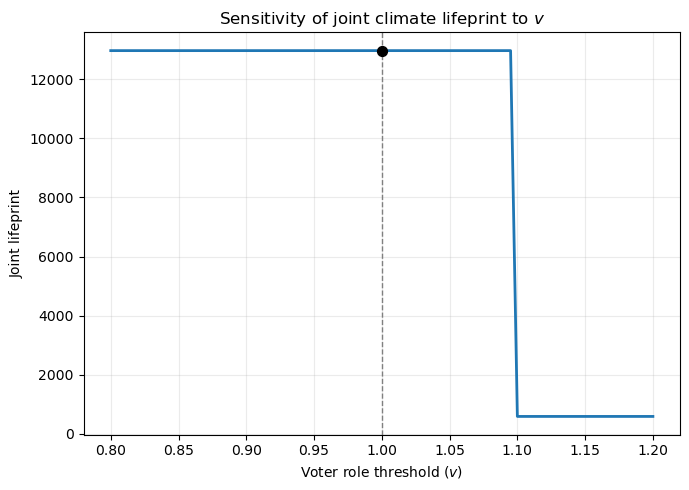

In [59]:
# Sensitivity analysis for parameter v
# range: v = [0.8,1.2]
#influenced scenario: Scenarios 5 and 6

v_values = np.linspace(0.8, 1.2, 81)

v_results = []

for v_test in v_values:

    # Scenario 5
    emissions_s5_test = scenario_5(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0, R_f0,
        v_test,  S_p
    )

    # Scenario 6
    emissions_s6_test = scenario_6(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0, R_f0,
        v_test, 
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta, sigma,
        m_1, m_2,
        p, S_p
    )

    v_results.append([
        v_test,
        emissions_s5_test - emissions_s2,
        emissions_s6_test - emissions_s2
    ])


# Table:

v_results_df = pd.DataFrame(
    v_results,
    columns=[
        "v",
        "E5_minus_E2",
        "E6_minus_E2"
    ]
)

v_results_df

print(v_results_df)


# Plot E5-E2

plt.figure(figsize=(7, 5))

plt.plot(
    v_results_df["v"],
    v_results_df["E5_minus_E2"],
    linewidth=2
)

# Baseline v
plt.axvline(
    x=v,
    color="gray",
    linestyle="--",
    linewidth=1
)

# Baseline result
plt.scatter(
    v,
    emissions_s5 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Voter role threshold ($v$)")
plt.ylabel(
    "Climate-skeptical politician's lifeprint"
)

plt.title(
    "Sensitivity of climate-skeptical politician's lifeprint to $v$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Plot for E6-E2

plt.figure(figsize=(7, 5))

plt.plot(
    v_results_df["v"],
    v_results_df["E6_minus_E2"],
    linewidth=2
)

# Baseline v
plt.axvline(
    x=v,
    color="gray",
    linestyle="--",
    linewidth=1
)

# Baseline result
plt.scatter(
    v,
    emissions_s6 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel("Voter role threshold ($v$)")
plt.ylabel(
    "Joint lifeprint"
)

plt.title(
    "Sensitivity of joint climate lifeprint to $v$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

    R_inf_CA  Scenario_3_emissions  E3_minus_E2
0     0.0100           3251.934729   -56.616391
1     0.0125           3237.854909   -70.696211
2     0.0150           3223.804798   -84.746322
3     0.0175           3209.784399   -98.766721
4     0.0200           3195.793710  -112.757410
5     0.0225           3181.832732  -126.718388
6     0.0250           3167.901465  -140.649655
7     0.0275           3153.999908  -154.551212
8     0.0300           3140.128062  -168.423058
9     0.0325           3126.285927  -182.265193
10    0.0350           3112.473502  -196.077617
11    0.0375           3098.690789  -209.860331
12    0.0400           3084.937786  -223.613334
13    0.0425           3071.214493  -237.336627
14    0.0450           3057.520911  -251.030208
15    0.0475           3043.857040  -264.694079
16    0.0500           3030.222880  -278.328240
17    0.0525           3016.618431  -291.932689
18    0.0550           3003.043692  -305.507428
19    0.0575           2989.498664  -319

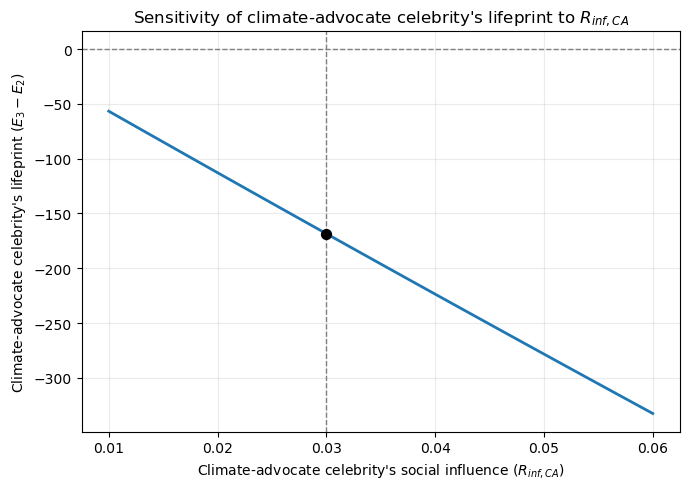

In [93]:
# Sensitivity analysis for parameter R_inf,CA
# range: R_inf,AC = [0.01,0.06]
#influenced scenario: Scenario 3

R_infCA_values = np.linspace(0.01, 0.06, 21)

R_infCA_results = []

for R_infCA_test in R_infCA_values:

    emissions_s3_test = scenario_3(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0, R_p0, R_f0,
        R_infCA_test
    )

    

    R_infCA_results.append([
        R_infCA_test,
        emissions_s3_test,
        emissions_s3_test - emissions_s2
    ])


# Table:

R_infCA_results_df = pd.DataFrame(
    R_infCA_results,
    columns=[
        "R_inf_CA",
        "Scenario_3_emissions",
        "E3_minus_E2"
    ]
)

R_infCA_results_df

print (R_infCA_results_df)




# Plot

plt.figure(figsize=(7, 5))

plt.plot(
    R_infCA_results_df["R_inf_CA"],
    R_infCA_results_df["E3_minus_E2"],
    linewidth=2
)


plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.axvline(
    x=R_inf_CA,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    R_inf_CA,
    emissions_s3 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel(
    "Climate-advocate celebrity's social influence ($R_{inf,CA}$)"
)

plt.ylabel(
    "Climate-advocate celebrity's lifeprint ($E_3-E_2$)"
)

plt.title(
    "Sensitivity of climate-advocate celebrity's lifeprint to $R_{inf,CA}$"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



    delta  Scenario_6_emissions   E6_minus_E2
0    0.30          16281.342054  12972.790934
1    0.31          16281.306854  12972.755734
2    0.32          16281.271654  12972.720534
3    0.33          16281.236454  12972.685334
4    0.34          16281.201254  12972.650134
5    0.35          16281.166054  12972.614934
6    0.36          16281.130854  12972.579734
7    0.37          16281.095654  12972.544534
8    0.38          16281.060454  12972.509334
9    0.39          16281.025254  12972.474134
10   0.40          16280.990054  12972.438934
11   0.41          16280.954854  12972.403734
12   0.42          16280.919654  12972.368534
13   0.43          16280.884454  12972.333334
14   0.44          16280.849254  12972.298134
15   0.45          16280.814054  12972.262934
16   0.46          16280.778854  12972.227734
17   0.47          16280.743654  12972.192534
18   0.48          16280.708454  12972.157334
19   0.49          16280.673254  12972.122134
20   0.50          16280.638054  1

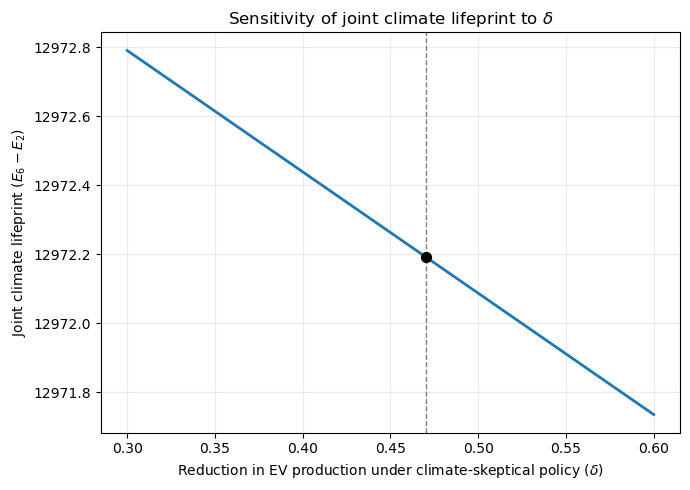

In [94]:
# Sensitivity analysis for parameter δ
# range: δ = [0.3,0.6]
#influenced scenario: Scenario 6

delta_values = np.linspace(0.30, 0.60, 31)

delta_results = []

for delta_test in delta_values:

    emissions_s6_test = scenario_6(
        E_h, H, Lambda, m_e,
        alpha, beta, gamma,
        theta_d, theta_nd,
        R_v0_CS, R_p0, R_f0,
        v,
        n_EV_sell, n_EV_pro,
        E_r, E_ext,
        delta_test, sigma,
        m_1, m_2,
        p, S_p
    )

   

    delta_results.append([
        delta_test,
        emissions_s6_test,
        emissions_s6_test - emissions_s2
    ])


# Table:

delta_results_df = pd.DataFrame(
    delta_results,
    columns=[
        "delta",
        "Scenario_6_emissions",
        "E6_minus_E2"
    ]
)

delta_results_df

print (delta_results_df)



# Plot:

plt.figure(figsize=(7, 5))

plt.plot(
    delta_results_df["delta"],
    delta_results_df["E6_minus_E2"],
    linewidth=2
)


plt.axvline(
    x=delta,
    color="gray",
    linestyle="--",
    linewidth=1
)


plt.scatter(
    delta,
    emissions_s6 - emissions_s2,
    color="black",
    s=50,
    zorder=3
)

plt.xlabel(
    "Reduction in EV production under climate-skeptical policy ($\\delta$)"
)

plt.ylabel(
    "Joint climate lifeprint ($E_6-E_2$)"
)

plt.title(
    "Sensitivity of joint climate lifeprint to $\\delta$"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
    useOffset=False
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


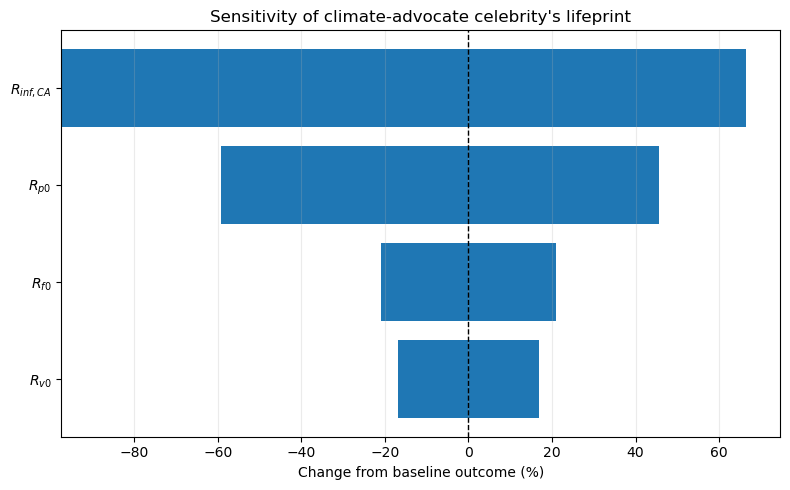

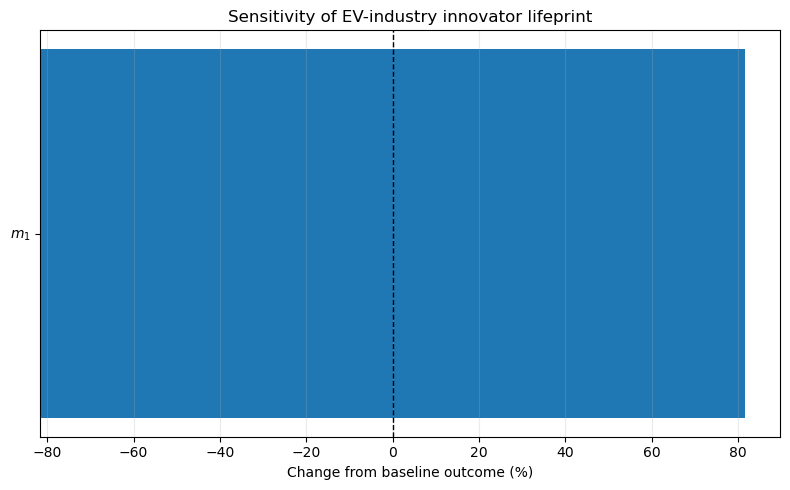

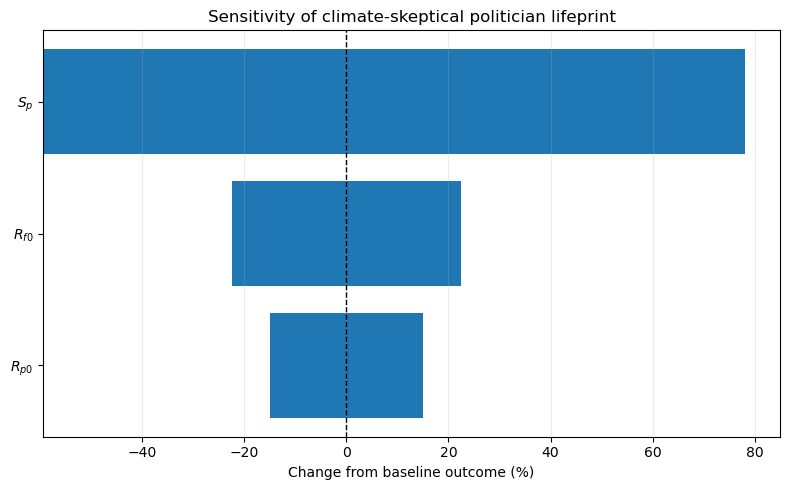

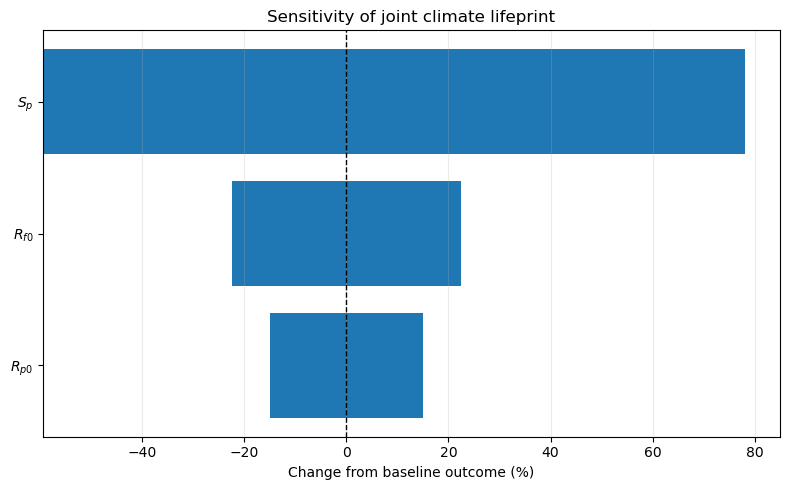

In [62]:
# Tornado plot for continuous parameters m_1, m_2, R_f0, R_p0, R_inf,AC, S_p

def make_tornado(parameter_results, baseline_output, title):

    tornado_data = []

    for parameter_name, df, output_column in parameter_results:

        
        output_min = df[output_column].min()
        output_max = df[output_column].max()

        
        change_min = (
            (output_min - baseline_output)
            / abs(baseline_output)
            * 100
        )

        change_max = (
            (output_max - baseline_output)
            / abs(baseline_output)
            * 100
        )

        tornado_data.append([
            parameter_name,
            change_min,
            change_max
        ])

    tornado_df = pd.DataFrame(
        tornado_data,
        columns=[
            "Parameter",
            "Minimum_change",
            "Maximum_change"
        ]
    )

    
    tornado_df["Sensitivity"] = tornado_df[
        ["Minimum_change", "Maximum_change"]
    ].abs().max(axis=1)

    
    tornado_df = tornado_df.sort_values(
        "Sensitivity",
        ascending=True
    )

    
    tornado_df["Width"] = (
        tornado_df["Maximum_change"]
        - tornado_df["Minimum_change"]
    )

    plt.figure(figsize=(8, 5))

    plt.barh(
        tornado_df["Parameter"],
        tornado_df["Width"],
        left=tornado_df["Minimum_change"]
    )

   
    plt.axvline(
        x=0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Change from baseline outcome (%)")
    plt.title(title)

    plt.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

    return tornado_df



# Tornado plot for E3 - E2


tornado_E3 = make_tornado(
    [
        (
            "$R_{f0}$",
            R_f0_results_df,
            "E3_minus_E2"
        ),
        (
            "$R_{p0}$",
            R_p0_results_df,
            "E3_minus_E2"
        ),

        
        (
            "$R_{v0}$",
            R_v0_results_df,
            "E3_minus_E2"
        ),

        (
            "$R_{inf,CA}$",
            R_infCA_results_df,
            "E3_minus_E2"
        )
    ],

    baseline_output=emissions_s3 - emissions_s2,

    title=(
        "Sensitivity of climate-advocate celebrity's lifeprint"
    )
)



# Tornado plot for E4 - E2

tornado_E4 = make_tornado(
    [
        (
            "$m_1$",
            m_1_results_df,
            "E4_minus_E2"
        ),
       # (
            #"$R_{f0}$",
           # R_f0_results_df,
           # "E4_minus_E2"
       # ),
       # (
       #     "$R_{p0}$",
       #     R_p0_results_df,
       #     "E4_minus_E2"
       # ),

        
       # (
          #  "$R_{v0}$",
         #   R_v0_results_df,
          #  "E4_minus_E2"
       # )
    ],

    baseline_output=emissions_s4 - emissions_s2,

    title=(
        "Sensitivity of EV-industry innovator lifeprint"
    )
)


# Tornado plot for E5 - E2


tornado_E5 = make_tornado(
    [
        (
            "$R_{f0}$",
            R_f0_results_df,
            "E5_minus_E2"
        ),
        (
            "$R_{p0}$",
            R_p0_results_df,
            "E5_minus_E2"
        ),
        (
            "$S_p$",
            S_p_results_df,
            "E5_minus_E2"
        ),
       # (
         #   "$R_{v0}^{CS}$",
        #    R_v0_CS_results_df,
        #    "E5_minus_E2"
       # )
    ],

    baseline_output=emissions_s5 - emissions_s2,

    title=(
        "Sensitivity of climate-skeptical politician lifeprint"
    )
)

# Tornado plot for E6 - E2


tornado_E6 = make_tornado(
    [
        
        (
            "$R_{f0}$",
            R_f0_results_df,
            "E6_minus_E2"
        ),
        (
            "$R_{p0}$",
            R_p0_results_df,
            "E6_minus_E2"
        ),
        (
            "$S_p$",
            S_p_results_df,
            "E6_minus_E2"
        ),
       
    ],

    baseline_output=emissions_s6 - emissions_s2,

    title=(
        "Sensitivity of joint climate lifeprint"
    )
)

